# Attention Analysis: Per-Rule Segment Attention on Airline RuleArena

This notebook explores how `openai/gpt-oss-120b` distributes attention across individual rule segments when solving airline baggage-fee problems.

**Sections:**
1. Load data & overview
2. Applicable vs non-applicable attention (cross-sample)
3. Layer-wise attention patterns
4. Attention evolution during generation
5. Accuracy–attention correlation
6. Per-sample deep dive

---

## Key Findings

- **Model already preferentially attends to applicable rules** at a mean 2.40× per-token ratio (range 1.44–3.11×) with no boosting — attention is semantically meaningful.
- **Top-attended segments are logically relevant**: carry-on rules, overweight-fee rules, and size-calculation rules dominate, all applicable to the tested problems.
- **Attention ratio does not predict correctness**: incorrect samples actually have a slightly *higher* ratio (2.63×) than correct ones (2.22×); per-token applicable attention is nearly identical across both groups.
- **All segments peak early**: every temporal cluster shows peak attention in the first ~25% of generation steps; variation across segments is only in decay rate, not peak timing.
- **Early/mid layers discriminate best**: layers 3, 5, 9, 19, 21 show the highest applicable/non-applicable ratio (~2.8–2.9×); later layers converge toward 1×.
- **Double-module architecture artifact**: only 18 of 36 captured modules are real attention layers (odd-indexed); even-indexed modules capture an auxiliary softmax ~650× weaker and are excluded from analysis.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

## 1. Load Data & Overview

In [2]:
RESULTS_DIR = Path("../results/attention_analysis/openai_gpt-oss-120b/airline/comp_0")

# Directory for saved figures
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures → {FIGURES_DIR.resolve()}")

# Load summary and config
with open(RESULTS_DIR / "summary.json") as f:
    summary = json.load(f)
with open(RESULTS_DIR / "config.json") as f:
    config = json.load(f)

# Load all per-sample JSONs — sort numerically so sample 2 precedes 10, etc.
samples = []
for p in sorted(RESULTS_DIR.glob("[0-9]*.json"), key=lambda p: int(p.stem)):
    if p.name in ("summary.json", "config.json"):
        continue
    with open(p) as f:
        samples.append(json.load(f))

print(f"Loaded {len(samples)} samples")
print(f"Model: {config['model']}")
print(f"Accuracy: {summary['accuracy']:.0%} ({summary['correct_count']}/{summary['total_count']})")
print(f"Layers: {samples[0]['num_layers']}  |  Segments: {samples[0]['num_segments']}")

Figures → /shared_data0/vitoriag/multi-rules/results/attention_analysis/openai_gpt-oss-120b/airline/comp_0/figures
Loaded 20 samples
Model: openai/gpt-oss-120b
Accuracy: 55% (11/20)
Layers: 36  |  Segments: 73


In [3]:
# Build a DataFrame for easy cross-sample analysis
rows = []
for s in samples:
    avs = s["applicable_vs_nonapplicable"]
    rows.append({
        "idx": s["sample_idx"],
        "is_correct": s["is_correct"],
        "input_tokens": s["input_length_tokens"],
        "output_tokens": s["output_length_tokens"],
        "num_steps": s["num_steps"],
        "total_app_attn": avs["total_applicable_attention"],
        "total_non_attn": avs["total_nonapplicable_attention"],
        "app_per_token": avs["applicable_per_token"],
        "non_per_token": avs["nonapplicable_per_token"],
        "ratio": avs["applicable_per_token"] / max(avs["nonapplicable_per_token"], 1e-12),
        "n_applicable": sum(s["segment_is_applicable"]),
        "n_nonapplicable": sum(not a for a in s["segment_is_applicable"]),
        "predicted": s["predicted_answer"],
        "truth": s["ground_truth_answer"],
    })

# Sort numerically by sample index so plots display in order 0, 1, 2, ...
df = pd.DataFrame(rows).sort_values("idx").reset_index(drop=True)
x = np.arange(len(df))  # bar-chart positions, shared across Section 2 plots
df.head()

,idx,is_correct,input_tokens,output_tokens,num_steps,total_app_attn,total_non_attn,app_per_token,non_per_token,ratio,n_applicable,n_nonapplicable,predicted,truth
0,0,True,5099,1899,1899,0.031919,0.021071,0.000026,0.000011,2.363636,28,45,1245,1245
1,1,True,5097,1852,1852,0.028801,0.017885,0.000023,0.000009,2.555556,29,44,1166,1166
2,2,False,5098,1846,1846,0.031764,0.016665,0.000025,0.000009,2.777778,29,44,999,949
3,3,True,5102,1748,1748,0.031231,0.023891,0.000027,0.000012,2.250000,27,46,1513,1513
4,4,True,5100,2803,2803,0.031304,0.029769,0.000024,0.000016,1.500000,29,44,1434,1434


## 2. Applicable vs Non-Applicable Attention

We measure attention two ways:

- **(a) Total attention mass** — the raw sum of attention weights on all tokens belonging to applicable (or non-applicable) segments, averaged across layers and generation steps. This is influenced by how many tokens each group has: a group with more tokens naturally captures more total attention.

- **(b) Per-token attention** — the total attention mass divided by the number of tokens in each group. This normalizes out the size difference, revealing whether the model attends *more intensely* to individual applicable-rule tokens vs non-applicable ones, regardless of how many tokens each group has.

- **(c) Per-token ratio** — the ratio of (b) for applicable over non-applicable. Values above 1 mean the model preferentially attends to applicable rules on a per-token basis.

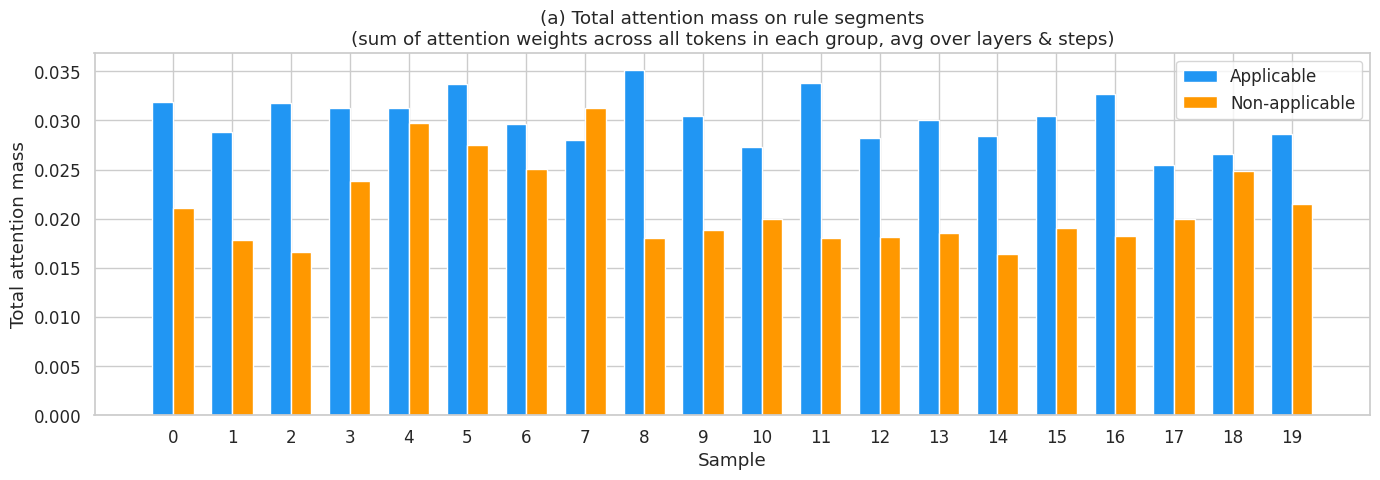

In [4]:
# (a) Total attention mass on applicable vs non-applicable segments
fig, ax = plt.subplots(figsize=(14, 5))
w = 0.35
ax.bar(x - w/2, df["total_app_attn"], w, label="Applicable", color="#2196F3")
ax.bar(x + w/2, df["total_non_attn"], w, label="Non-applicable", color="#FF9800")
ax.set_xlabel("Sample")
ax.set_ylabel("Total attention mass")
ax.set_title("(a) Total attention mass on rule segments\n"
             "(sum of attention weights across all tokens in each group, avg over layers & steps)")
ax.set_xticks(x)
ax.set_xticklabels(df["idx"])
ax.legend()
fig.tight_layout()
plt.show()

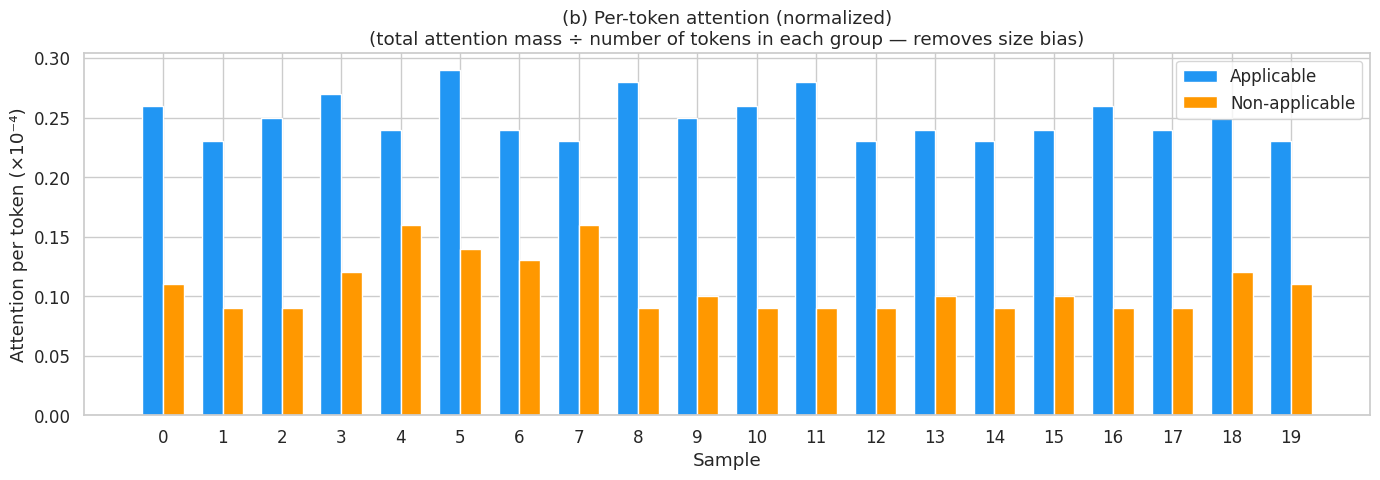

In [5]:
# (b) Per-token attention (normalized by number of tokens in each group)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, df["app_per_token"] * 1e4, w, label="Applicable", color="#2196F3")
ax.bar(x + w/2, df["non_per_token"] * 1e4, w, label="Non-applicable", color="#FF9800")
ax.set_xlabel("Sample")
ax.set_ylabel("Attention per token (×10⁻⁴)")
ax.set_title("(b) Per-token attention (normalized)\n"
             "(total attention mass ÷ number of tokens in each group — removes size bias)")
ax.set_xticks(x)
ax.set_xticklabels(df["idx"])
ax.legend()
fig.tight_layout()
plt.show()

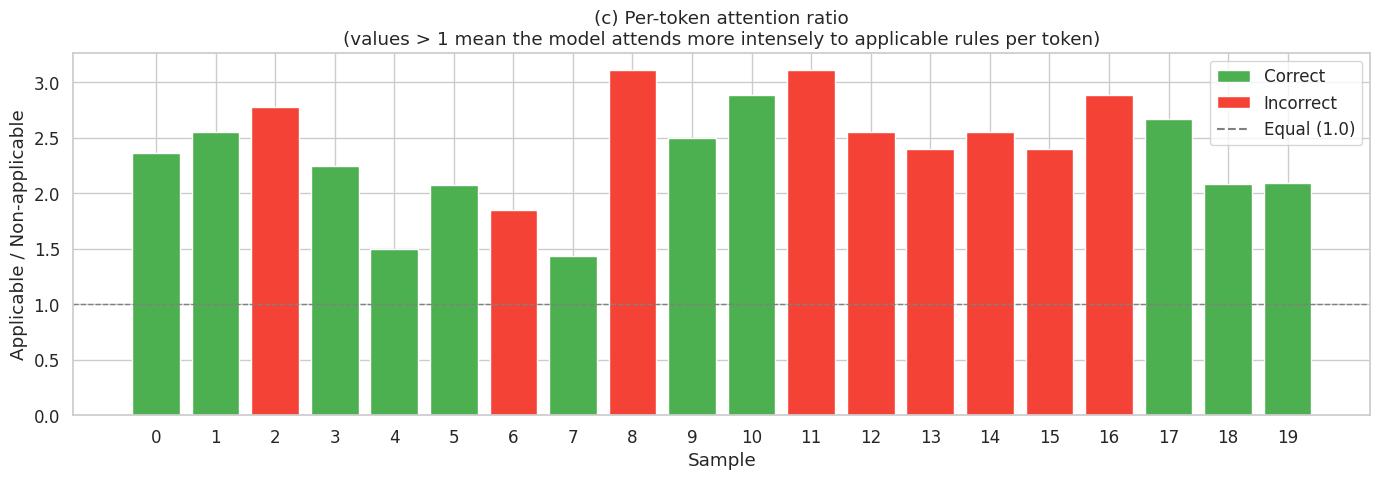

Mean per-token ratio (app / non-app): 2.40x
Median: 2.45x  |  Min: 1.44x  |  Max: 3.11x


In [6]:
# (c) Per-token attention ratio (applicable / non-applicable), colored by correctness
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#4CAF50" if c else "#F44336" for c in df["is_correct"]]
ax.bar(x, df["ratio"], color=colors)
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("Sample")
ax.set_ylabel("Applicable / Non-applicable")
ax.set_title("(c) Per-token attention ratio\n"
             "(values > 1 mean the model attends more intensely to applicable rules per token)")
ax.set_xticks(x)
ax.set_xticklabels(df["idx"])
ax.legend(handles=[
    Patch(facecolor="#4CAF50", label="Correct"),
    Patch(facecolor="#F44336", label="Incorrect"),
    plt.Line2D([0], [0], color="gray", ls="--", label="Equal (1.0)"),
])
fig.tight_layout()
plt.show()

print(f"Mean per-token ratio (app / non-app): {df['ratio'].mean():.2f}x")
print(f"Median: {df['ratio'].median():.2f}x  |  Min: {df['ratio'].min():.2f}x  |  Max: {df['ratio'].max():.2f}x")

## 3. Layer-Wise Attention Patterns

How does the gap between applicable and non-applicable attention vary across layers?

In [7]:
# Build per-layer applicable vs non-applicable attention, averaged across samples
num_layers = samples[0]["num_layers"]
segment_names = samples[0]["segment_names"]
num_segments = len(segment_names)

layer_app = np.zeros(num_layers)
layer_non = np.zeros(num_layers)

for s in samples:
    app_mask = np.array(s["segment_is_applicable"])
    non_mask = ~app_mask
    num_tokens = np.array(s["segment_num_tokens"])
    app_tokens = num_tokens[app_mask].sum()
    non_tokens = num_tokens[non_mask].sum()

    layer_seg = np.array(s["attention_per_layer_segment"])  # [layers, segments]
    for l in range(num_layers):
        layer_app[l] += layer_seg[l, app_mask].sum() / max(app_tokens, 1)
        layer_non[l] += layer_seg[l, non_mask].sum() / max(non_tokens, 1)

layer_app /= len(samples)
layer_non /= len(samples)

# -----------------------------------------------------------------------
# Detect the "double-module" pattern: find_attention_modules() may find
# both an outer self_attn wrapper and an inner attention sub-module per
# transformer layer.  The outer captures the first 4-D softmax it sees,
# which in some architectures (e.g. gpt-oss-120b) is a small auxiliary
# softmax (seq_k << input_length), not the actual attention weights.
# Result: alternating layers show ~650x lower values.
# We detect this and keep only the "real" (high-mass) layers.
# -----------------------------------------------------------------------
_avg_sums = np.array(
    [np.array(s["attention_per_layer_segment"]).sum(axis=1) for s in samples]
).mean(axis=0)

_even_mean = _avg_sums[::2].mean()   if num_layers > 1 else float(_avg_sums[0])
_odd_mean  = _avg_sums[1::2].mean()  if num_layers > 1 else 0.0
_THRESHOLD = 50  # one set must be 50× stronger to flag the pattern

if _odd_mean > _THRESHOLD * max(_even_mean, 1e-15):
    real_layer_indices = np.arange(1, num_layers, 2)
    print(f"Double-module architecture detected: odd-indexed layers are the real "
          f"attention layers ({len(real_layer_indices)} of {num_layers} found modules).\n"
          f"Even-indexed layers are outer wrappers that capture a spurious small softmax;\n"
          f"they are excluded from all layer-wise plots.")
elif _even_mean > _THRESHOLD * max(_odd_mean, 1e-15):
    real_layer_indices = np.arange(0, num_layers, 2)
    print(f"Double-module architecture detected: even-indexed layers are the real "
          f"attention layers ({len(real_layer_indices)} of {num_layers} found modules).")
else:
    real_layer_indices = np.arange(num_layers)
    print(f"No double-module pattern detected — using all {num_layers} layers.")

layer_app_real = layer_app[real_layer_indices]
layer_non_real = layer_non[real_layer_indices]

Double-module architecture detected: odd-indexed layers are the real attention layers (18 of 36 found modules).
Even-indexed layers are outer wrappers that capture a spurious small softmax;
they are excluded from all layer-wise plots.


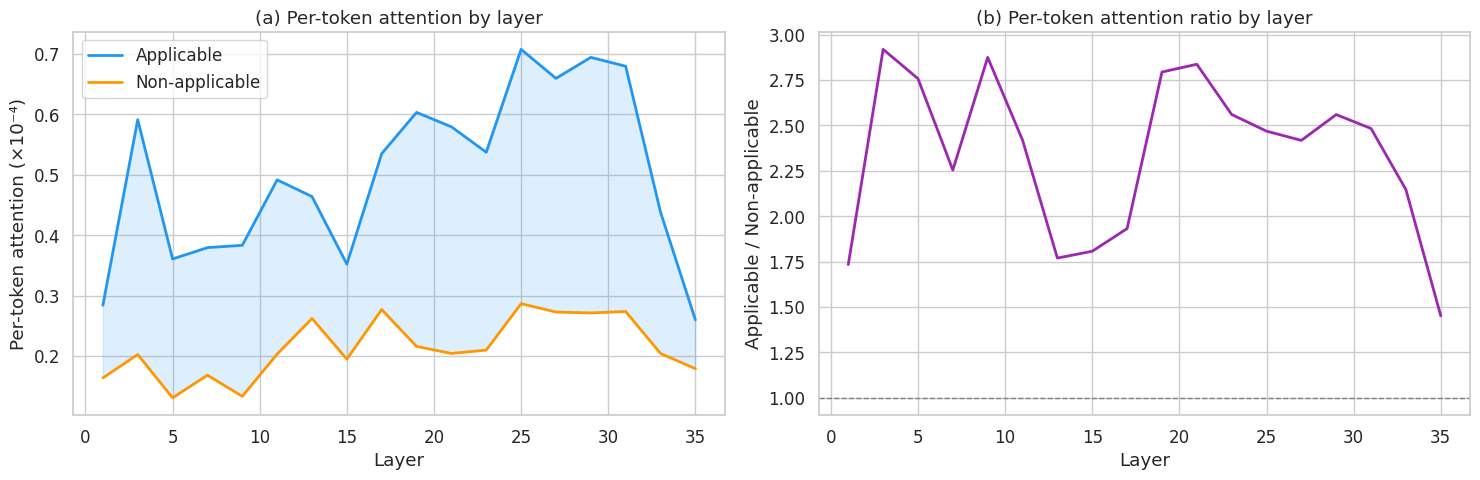

Top-5 layers by app/non-app ratio:
  Layer 3: ratio=2.92x  (app=0.591, non=0.203 ×10⁻⁴)
  Layer 9: ratio=2.87x  (app=0.383, non=0.133 ×10⁻⁴)
  Layer 21: ratio=2.84x  (app=0.580, non=0.204 ×10⁻⁴)
  Layer 19: ratio=2.79x  (app=0.603, non=0.216 ×10⁻⁴)
  Layer 5: ratio=2.76x  (app=0.361, non=0.131 ×10⁻⁴)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Per-token attention by layer (real layers only)
ax = axes[0]
ax.plot(real_layer_indices, layer_app_real * 1e4, label="Applicable", color="#2196F3", lw=2)
ax.plot(real_layer_indices, layer_non_real * 1e4, label="Non-applicable", color="#FF9800", lw=2)
ax.fill_between(real_layer_indices, layer_app_real * 1e4, layer_non_real * 1e4,
                alpha=0.15, color="#2196F3")
ax.set_xlabel("Layer")
ax.set_ylabel("Per-token attention (×10⁻⁴)")
ax.set_title("(a) Per-token attention by layer")
ax.legend()

# (b) Ratio by layer
ax = axes[1]
ratio_by_layer = layer_app_real / np.maximum(layer_non_real, 1e-15)
ax.plot(real_layer_indices, ratio_by_layer, color="#9C27B0", lw=2)
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("Layer")
ax.set_ylabel("Applicable / Non-applicable")
ax.set_title("(b) Per-token attention ratio by layer")

fig.tight_layout()
plt.show()

top5_pos = np.argsort(ratio_by_layer)[::-1][:5]
print("Top-5 layers by app/non-app ratio:")
for i in top5_pos:
    l = real_layer_indices[i]
    print(f"  Layer {l}: ratio={ratio_by_layer[i]:.2f}x  "
          f"(app={layer_app_real[i]*1e4:.3f}, non={layer_non_real[i]*1e4:.3f} ×10⁻⁴)")

Saved → ../results/attention_analysis/openai_gpt-oss-120b/airline/comp_0/figures/cross_sample_layer_segment.png


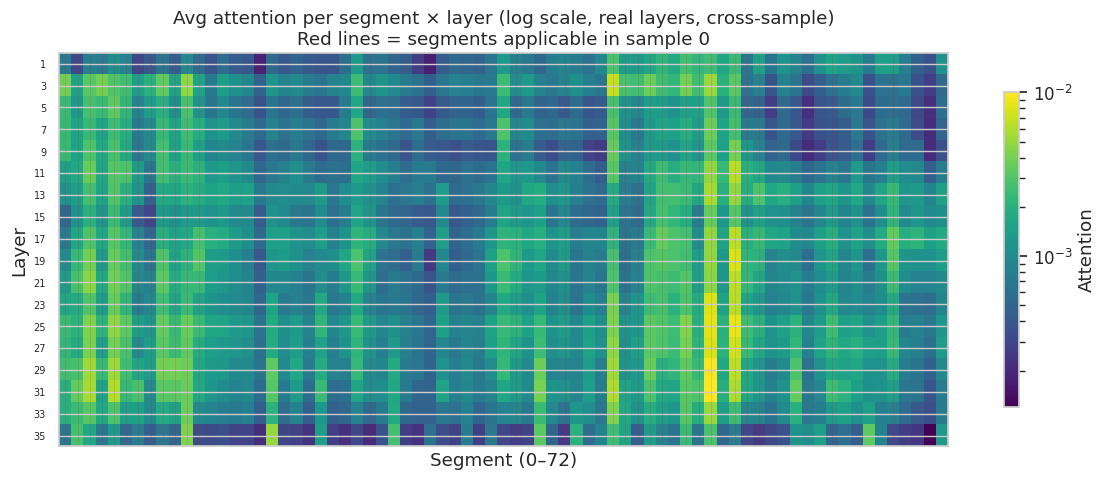

In [9]:
# Heatmap: average attention per segment per layer (across all samples, real layers only)
avg_layer_seg = np.zeros((num_layers, num_segments))
for s in samples:
    avg_layer_seg += np.array(s["attention_per_layer_segment"])
avg_layer_seg /= len(samples)

avg_layer_seg_real = avg_layer_seg[real_layer_indices, :]

fig, ax = plt.subplots(figsize=(12, 5))
pos_vals = avg_layer_seg_real[avg_layer_seg_real > 0]
if len(pos_vals) > 0:
    im = ax.imshow(avg_layer_seg_real, aspect="auto", cmap="viridis",
                   norm=mcolors.LogNorm(vmin=max(pos_vals.min(), 1e-8),
                                         vmax=avg_layer_seg_real.max()))
else:
    im = ax.imshow(avg_layer_seg_real, aspect="auto", cmap="viridis")
ax.set_xlabel(f"Segment (0–{num_segments - 1})")
ax.set_ylabel("Layer")
ax.set_title("Avg attention per segment × layer (log scale, real layers, cross-sample)\n"
             "Red lines = segments applicable in sample 0")
ax.set_xticks([])
ax.set_yticks(range(len(real_layer_indices)))
ax.set_yticklabels([str(l) for l in real_layer_indices], fontsize=7)
plt.colorbar(im, ax=ax, label="Attention", shrink=0.8)

app_indices = [i for i, a in enumerate(samples[0]["segment_is_applicable"]) if a]
for i in app_indices:
    ax.axvline(i, color="red", alpha=0.2, lw=0.5)

fig.tight_layout()
out_path = FIGURES_DIR / "cross_sample_layer_segment.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

## 4. Attention Evolution During Generation

How does attention on applicable rules change across generation steps (prefill vs early/mid/late generation)?

In [10]:
def load_attention_cube(sample_idx):
    """Load the full [layers, steps, segments] cube for a sample."""
    npz_path = RESULTS_DIR / f"{sample_idx}_attention.npz"
    return np.load(npz_path)["attention"]

# Load cubes for a few representative samples (correct + incorrect)
correct_idxs = df[df["is_correct"]]["idx"].tolist()[:3]
incorrect_idxs = df[~df["is_correct"]]["idx"].tolist()[:3]
example_idxs = correct_idxs + incorrect_idxs
print(f"Loading cubes for samples: {example_idxs}")
print(f"  Correct: {correct_idxs}  |  Incorrect: {incorrect_idxs}")

Loading cubes for samples: [0, 1, 3, 2, 6, 8]
  Correct: [0, 1, 3]  |  Incorrect: [2, 6, 8]


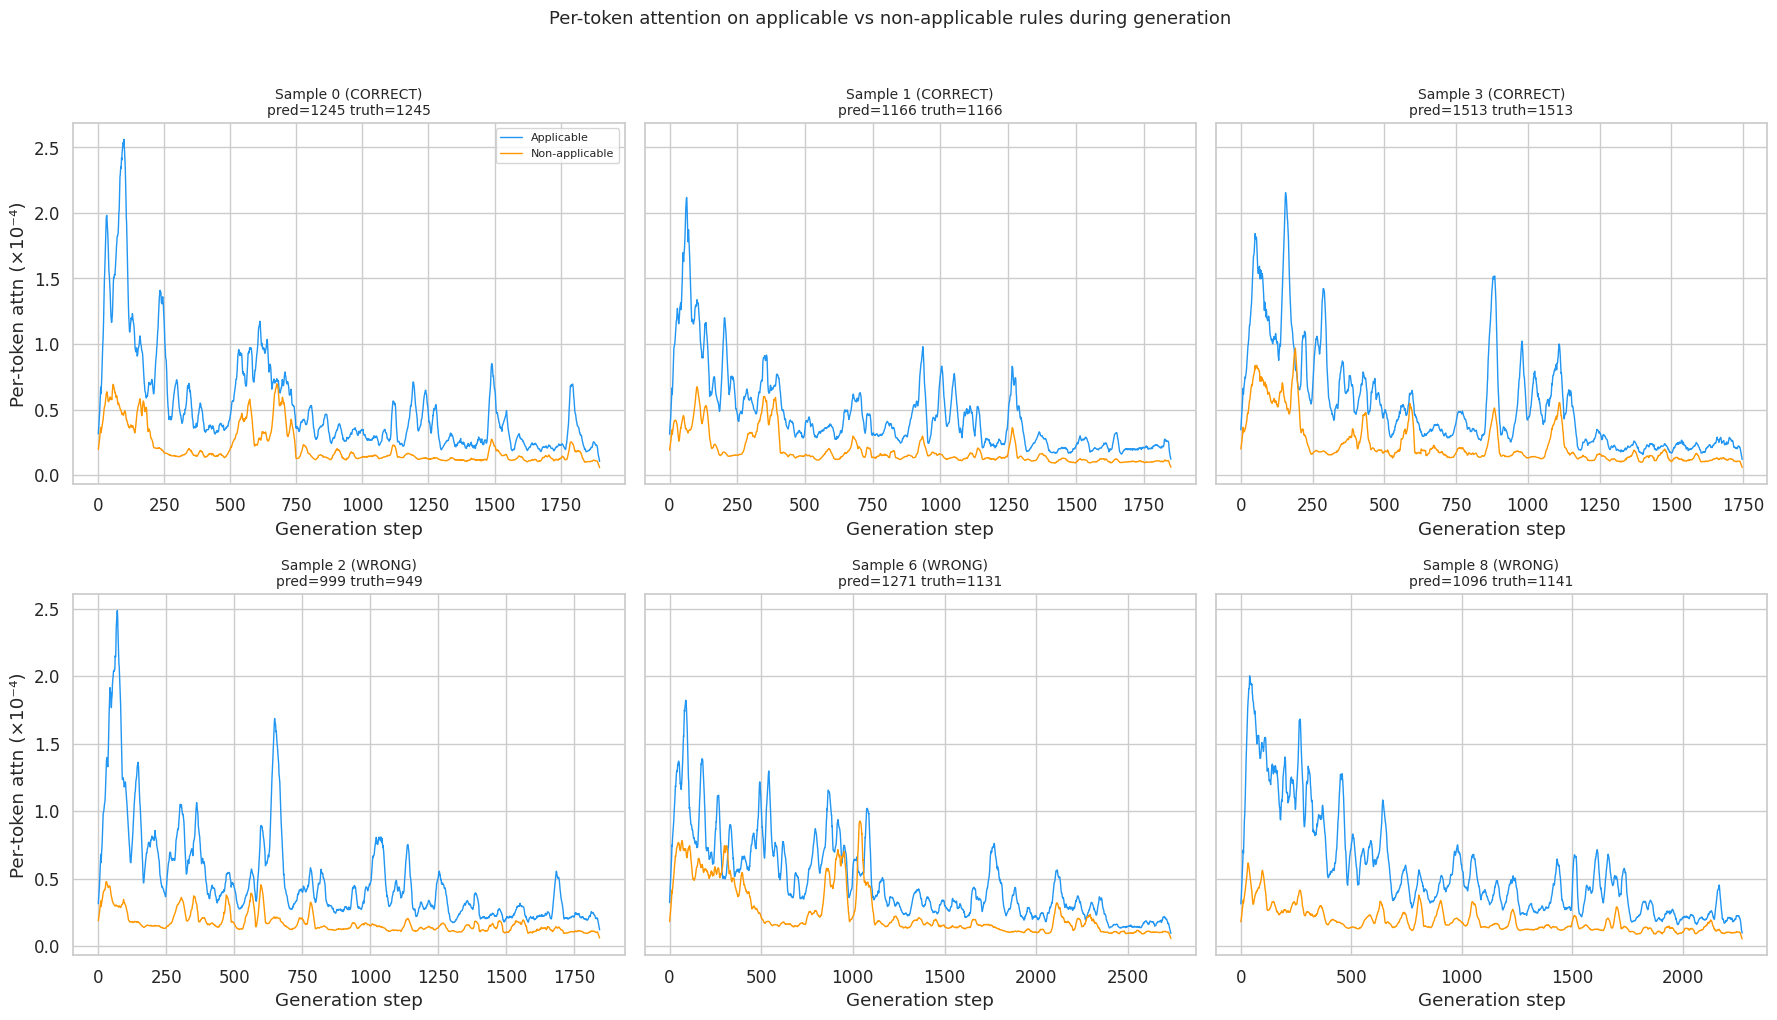

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")

for col, sidx in enumerate(example_idxs):
    row = 0 if sidx in correct_idxs else 1
    col_idx = col if row == 0 else col - len(correct_idxs)
    ax = axes[row, col_idx]

    cube = load_attention_cube(sidx)
    s = samples[sidx]
    app_mask = np.array(s["segment_is_applicable"])
    non_mask = ~app_mask
    num_tokens = np.array(s["segment_num_tokens"])
    app_tok = num_tokens[app_mask].sum()
    non_tok = num_tokens[non_mask].sum()

    # Average across real layers only → [steps, segments]
    step_seg = cube[real_layer_indices].mean(axis=0)
    n_steps = step_seg.shape[0]

    # Smooth with a rolling window for readability
    window = max(1, n_steps // 100)
    app_series = step_seg[:, app_mask].sum(axis=1) / max(app_tok, 1)
    non_series = step_seg[:, non_mask].sum(axis=1) / max(non_tok, 1)

    if window > 1:
        kernel = np.ones(window) / window
        app_smooth = np.convolve(app_series, kernel, mode="same")
        non_smooth = np.convolve(non_series, kernel, mode="same")
    else:
        app_smooth, non_smooth = app_series, non_series

    steps = np.arange(n_steps)
    ax.plot(steps, app_smooth * 1e4, label="Applicable", color="#2196F3", lw=1)
    ax.plot(steps, non_smooth * 1e4, label="Non-applicable", color="#FF9800", lw=1)

    status = "CORRECT" if s["is_correct"] else "WRONG"
    ax.set_title(f"Sample {sidx} ({status})\npred={s['predicted_answer']} truth={s['ground_truth_answer']}",
                 fontsize=10)
    ax.set_xlabel("Generation step")
    if col_idx == 0:
        ax.set_ylabel("Per-token attn (×10⁻⁴)")
    if row == 0 and col_idx == 0:
        ax.legend(fontsize=8)

fig.suptitle("Per-token attention on applicable vs non-applicable rules during generation",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

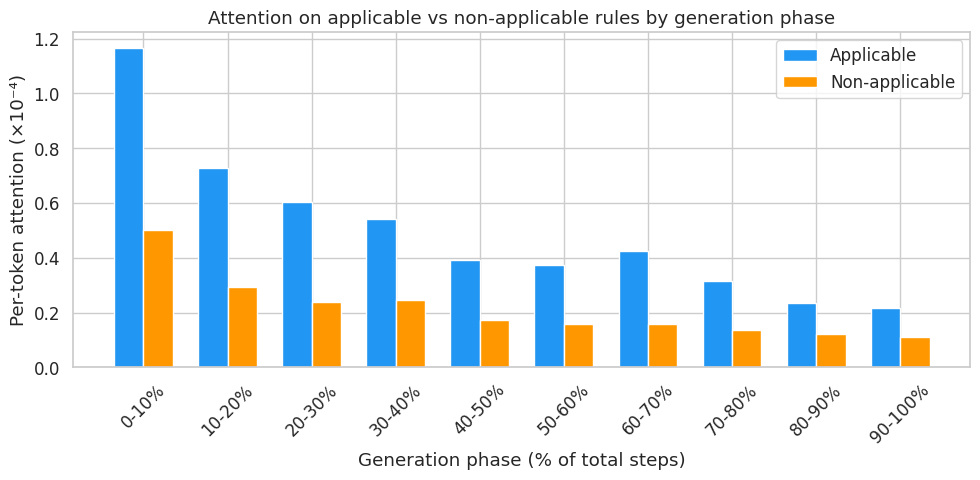

In [12]:
# Aggregate across ALL samples: split generation into 10 equal phases
N_PHASES = 10
phase_app = np.zeros(N_PHASES)
phase_non = np.zeros(N_PHASES)
count = 0

for s in samples:
    cube = load_attention_cube(s["sample_idx"])
    app_mask = np.array(s["segment_is_applicable"])
    non_mask = ~app_mask
    num_tokens = np.array(s["segment_num_tokens"])
    app_tok = num_tokens[app_mask].sum()
    non_tok = num_tokens[non_mask].sum()

    step_seg = cube[real_layer_indices].mean(axis=0)  # [steps, segments]
    n_steps = step_seg.shape[0]
    boundaries = np.linspace(0, n_steps, N_PHASES + 1, dtype=int)

    for p in range(N_PHASES):
        chunk = step_seg[boundaries[p]:boundaries[p+1]]
        if chunk.shape[0] == 0:
            continue
        phase_app[p] += chunk[:, app_mask].sum(axis=1).mean() / max(app_tok, 1)
        phase_non[p] += chunk[:, non_mask].sum(axis=1).mean() / max(non_tok, 1)
    count += 1

phase_app /= count
phase_non /= count

fig, ax = plt.subplots(figsize=(10, 5))
phase_labels = [f"{int(i/N_PHASES*100)}-{int((i+1)/N_PHASES*100)}%" for i in range(N_PHASES)]
x_ph = np.arange(N_PHASES)
w_ph = 0.35
ax.bar(x_ph - w_ph/2, phase_app * 1e4, w_ph, label="Applicable", color="#2196F3")
ax.bar(x_ph + w_ph/2, phase_non * 1e4, w_ph, label="Non-applicable", color="#FF9800")
ax.set_xticks(x_ph)
ax.set_xticklabels(phase_labels, rotation=45)
ax.set_xlabel("Generation phase (% of total steps)")
ax.set_ylabel("Per-token attention (×10⁻⁴)")
ax.set_title("Attention on applicable vs non-applicable rules by generation phase")
ax.legend()
fig.tight_layout()
plt.show()

### 4b. Per-Segment Attention Over Generation (Cross-Sample)

Each row is a rule segment; the x-axis is generation phase (0–100 %); colour is attention averaged over real layers and all samples.
Segments are grouped: those applicable in the **majority of samples** appear at the top (sorted by total attention), the rest at the bottom.
A red line marks the boundary between the two groups.

Saved → ../results/attention_analysis/openai_gpt-oss-120b/airline/comp_0/figures/cross_sample_seg_phase_heatmap.png


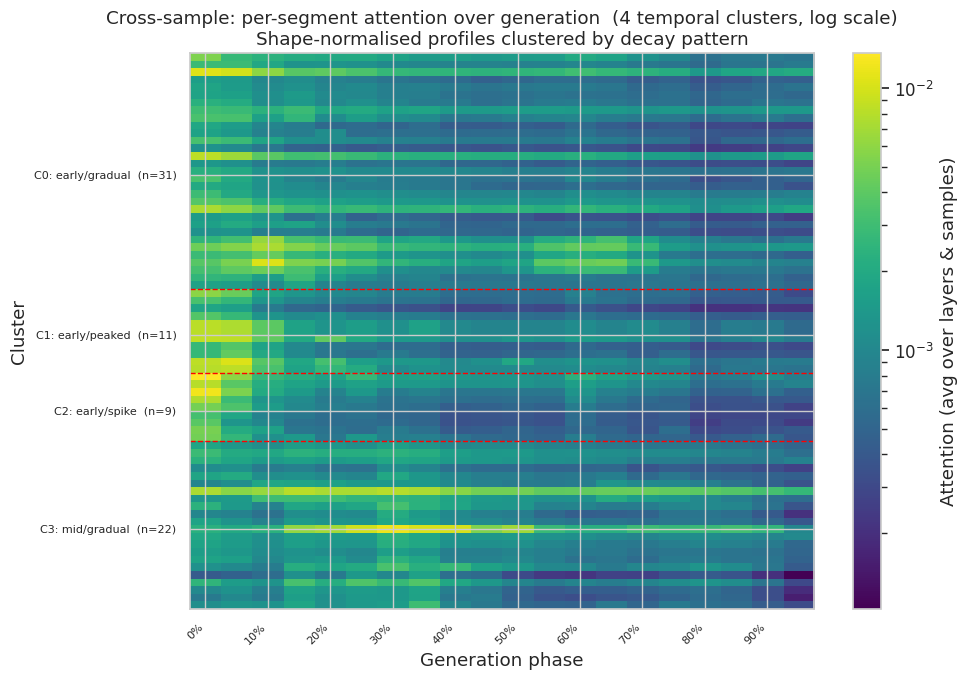


Cluster summary:
  C0 (early/gradual, n=31): peak phase=0 (0%), cv=0.50
  C1 (early/peaked, n=11): peak phase=0 (0%), cv=1.01
  C2 (early/spike, n=9): peak phase=0 (0%), cv=1.16
  C3 (mid/gradual, n=22): peak phase=6 (30%), cv=0.40


In [13]:
# Cross-sample heatmap: segments × generation phases, clustered by temporal attention profile
from sklearn.cluster import KMeans

N_PHASES_HM = 20
N_CLUSTERS = 4   # adjust to taste

seg_phase = np.zeros((N_PHASES_HM, num_segments))
for s_hm in samples:
    cube_hm = load_attention_cube(s_hm["sample_idx"])
    step_seg_hm = cube_hm[real_layer_indices].mean(axis=0)  # [steps, segments]
    n_steps_hm = step_seg_hm.shape[0]
    bounds = np.linspace(0, n_steps_hm, N_PHASES_HM + 1, dtype=int)
    for p in range(N_PHASES_HM):
        chunk = step_seg_hm[bounds[p]:bounds[p + 1]]
        if chunk.shape[0] > 0:
            seg_phase[p] += chunk.mean(axis=0)
seg_phase /= len(samples)

# ── Temporal clustering ────────────────────────────────────────────────────────
profiles = seg_phase.T  # [num_segments, N_PHASES_HM]
# Normalise so KMeans clusters by *shape* (decay pattern) not magnitude
totals = profiles.sum(axis=1, keepdims=True)
profiles_norm = profiles / np.maximum(totals, 1e-15)


def _cluster_name(centroid):
    """Describe a normalised centroid by timing and decay shape.

    Since attention almost always peaks early in generation, we distinguish
    clusters by *how quickly* attention decays (cv) and *how early* the
    peak is (frac of total phases).
    """
    n = len(centroid)
    frac = centroid.argmax() / n
    cv   = centroid.std() / (centroid.mean() + 1e-15)
    timing = ("early" if frac < 0.25 else
              "mid"   if frac < 0.65 else "late")
    shape  = ("spike"   if cv > 1.1  else
              "peaked"  if cv > 0.7  else
              "gradual" if cv > 0.35 else "flat")
    return f"{timing}/{shape}"


km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
raw_labels = km.fit_predict(profiles_norm)

# Re-rank cluster IDs: 0 = earliest-peaking centroid
centroid_peaks = km.cluster_centers_.argmax(axis=1)
rank_map = np.empty(N_CLUSTERS, dtype=int)
rank_map[np.argsort(centroid_peaks)] = np.arange(N_CLUSTERS)
cluster_labels_cs = rank_map[raw_labels]

# Sort segments: cluster 0 first; within each cluster sort by individual peak phase
seg_order_cs = []
cluster_boundaries_cs = [0]
cluster_names_cs = []
for k in range(N_CLUSTERS):
    orig_k = np.argsort(centroid_peaks)[k]
    members = np.where(cluster_labels_cs == k)[0]
    peak_within = profiles_norm[members].argmax(axis=1)
    seg_order_cs.extend(members[np.argsort(peak_within)])
    cluster_boundaries_cs.append(len(seg_order_cs))
    cluster_names_cs.append(_cluster_name(km.cluster_centers_[orig_k]))

seg_order_cs = np.array(seg_order_cs)

# ── Plot ───────────────────────────────────────────────────────────────────────
display_hm = seg_phase[:, seg_order_cs].T          # [num_segments, N_PHASES_HM]
phase_labels_hm = [f"{int(p/N_PHASES_HM*100)}%" for p in range(N_PHASES_HM)]

fig, ax = plt.subplots(figsize=(10, 7))
pos_vals = display_hm[display_hm > 0]
if len(pos_vals) > 0:
    im = ax.imshow(display_hm, aspect="auto", cmap="viridis",
                   norm=mcolors.LogNorm(vmin=max(pos_vals.min(), 1e-9),
                                         vmax=display_hm.max()))
else:
    im = ax.imshow(display_hm, aspect="auto", cmap="viridis")

for b in cluster_boundaries_cs[1:-1]:
    ax.axhline(b - 0.5, color="red", lw=1, ls="--")

mids = [(cluster_boundaries_cs[k] + cluster_boundaries_cs[k+1]) / 2
        for k in range(N_CLUSTERS)]
labels_y = [f"C{k}: {cluster_names_cs[k]}  "
            f"(n={cluster_boundaries_cs[k+1]-cluster_boundaries_cs[k]})"
            for k in range(N_CLUSTERS)]
ax.set_yticks(mids)
ax.set_yticklabels(labels_y, fontsize=8)

ax.set_xlabel("Generation phase")
ax.set_ylabel("Cluster")
ax.set_title(
    f"Cross-sample: per-segment attention over generation  "
    f"({N_CLUSTERS} temporal clusters, log scale)\n"
    f"Shape-normalised profiles clustered by decay pattern"
)
ax.set_xticks(range(0, N_PHASES_HM, 2))
ax.set_xticklabels([phase_labels_hm[i] for i in range(0, N_PHASES_HM, 2)],
                    rotation=45, ha="right", fontsize=8)
plt.colorbar(im, ax=ax, label="Attention (avg over layers & samples)")
fig.tight_layout()

out_path = FIGURES_DIR / "cross_sample_seg_phase_heatmap.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

print("\nCluster summary:")
for k in range(N_CLUSTERS):
    orig_k = np.argsort(centroid_peaks)[k]
    start, end = cluster_boundaries_cs[k], cluster_boundaries_cs[k+1]
    peak_p = km.cluster_centers_[orig_k].argmax()
    cv_k   = km.cluster_centers_[orig_k].std() / km.cluster_centers_[orig_k].mean()
    print(f"  C{k} ({cluster_names_cs[k]}, n={end-start}): "
          f"peak phase={peak_p} ({int(peak_p/N_PHASES_HM*100)}%), cv={cv_k:.2f}")

## 5. Accuracy–Attention Correlation

Do correct samples attend more to applicable rules?

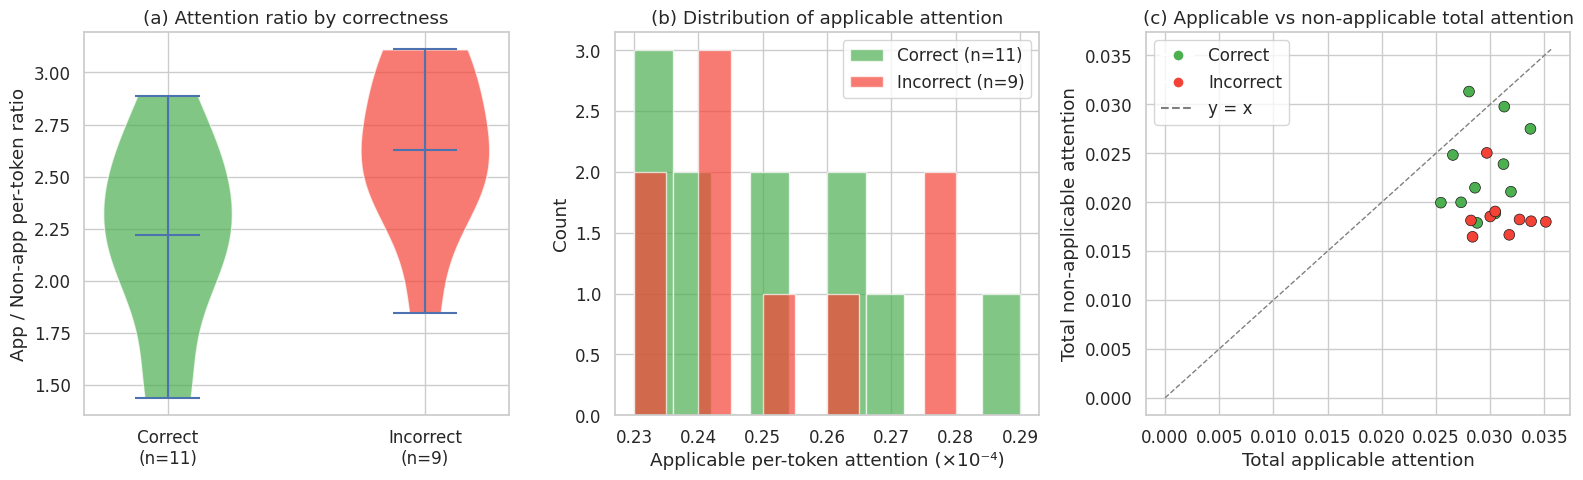

Mean ratio — Correct: 2.22x | Incorrect: 2.63x
Mean app per-token — Correct: 0.2500 | Incorrect: 0.2500 (×10⁻⁴)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Per-token ratio: correct vs incorrect
ax = axes[0]
correct_ratios = df[df["is_correct"]]["ratio"]
incorrect_ratios = df[~df["is_correct"]]["ratio"]
parts = ax.violinplot([correct_ratios, incorrect_ratios], positions=[0, 1], showmeans=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(["#4CAF50", "#F44336"][i])
    pc.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"Correct\n(n={len(correct_ratios)})",
                     f"Incorrect\n(n={len(incorrect_ratios)})"])
ax.set_ylabel("App / Non-app per-token ratio")
ax.set_title("(a) Attention ratio by correctness")

# (b) Applicable per-token attention distribution
ax = axes[1]
correct_app = df[df["is_correct"]]["app_per_token"] * 1e4
incorrect_app = df[~df["is_correct"]]["app_per_token"] * 1e4
ax.hist(correct_app, bins=10, alpha=0.7, label=f"Correct (n={len(correct_app)})", color="#4CAF50")
ax.hist(incorrect_app, bins=10, alpha=0.7, label=f"Incorrect (n={len(incorrect_app)})", color="#F44336")
ax.set_xlabel("Applicable per-token attention (×10⁻⁴)")
ax.set_ylabel("Count")
ax.set_title("(b) Distribution of applicable attention")
ax.legend()

# (c) Scatter: applicable attention vs total attention
ax = axes[2]
colors = ["#4CAF50" if c else "#F44336" for c in df["is_correct"]]
ax.scatter(df["total_app_attn"], df["total_non_attn"], c=colors, s=60, edgecolors="k", lw=0.5)
ax.set_xlabel("Total applicable attention")
ax.set_ylabel("Total non-applicable attention")
ax.set_title("(c) Applicable vs non-applicable total attention")
ax.plot([0, ax.get_xlim()[1]], [0, ax.get_xlim()[1]], "--", color="gray", lw=1, label="y = x")
ax.legend(handles=[
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#4CAF50", markersize=8, label="Correct"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#F44336", markersize=8, label="Incorrect"),
    plt.Line2D([0], [0], color="gray", ls="--", label="y = x"),
])

fig.tight_layout()
plt.show()

print(f"Mean ratio — Correct: {correct_ratios.mean():.2f}x | Incorrect: {incorrect_ratios.mean():.2f}x")
print(f"Mean app per-token — Correct: {correct_app.mean():.4f} | Incorrect: {incorrect_app.mean():.4f} (×10⁻⁴)")

## 6. Per-Sample Deep Dive

Select a sample below to inspect its attention patterns in detail.

In [22]:
# ============================================================
# SELECT A SAMPLE HERE
# ============================================================
SAMPLE_IDX = 1  # <-- Change this to explore different samples
# ============================================================

s = samples[SAMPLE_IDX]
cube = load_attention_cube(s["sample_idx"])
app_mask = np.array(s["segment_is_applicable"])
num_tokens_seg = np.array(s["segment_num_tokens"])

print(f"Sample {s['sample_idx']}")
print(f"  Correct: {s['is_correct']}  |  Predicted: {s['predicted_answer']}  |  Truth: {s['ground_truth_answer']}")
print(f"  Route: {s['problem_info']['routine']}  |  Class: {s['problem_info']['customer_class']}")
print(f"  Bags: {len(s['problem_info']['bag_list'])} (incl. carry-on)")
print(f"  Input tokens: {s['input_length_tokens']}  |  Output tokens: {s['output_length_tokens']}")
print(f"  Layers: {s['num_layers']}  |  Steps: {s['num_steps']}  |  Segments: {s['num_segments']}")
print(f"  Applicable segments: {app_mask.sum()} / {len(app_mask)}")
print(f"  Attention cube shape: {cube.shape}")

Sample 1
  Correct: True  |  Predicted: 1166  |  Truth: 1166
  Route: U.S.  |  Class: Business
  Bags: 5 (incl. carry-on)
  Input tokens: 5097  |  Output tokens: 1852
  Layers: 36  |  Steps: 1852  |  Segments: 73
  Applicable segments: 29 / 73
  Attention cube shape: (36, 1852, 73)


In [23]:
# Table: per-segment attention with applicability flag
seg_df = pd.DataFrame({
    "segment": s["segment_names"],
    "applicable": s["segment_is_applicable"],
    "num_tokens": s["segment_num_tokens"],
    "avg_attention": s["attention_per_segment"],
})
seg_df["attn_per_token"] = seg_df["avg_attention"] / seg_df["num_tokens"].clip(lower=1)
seg_df = seg_df.sort_values("attn_per_token", ascending=False)

# Mark applicable segments with a symbol (avoids jinja2 dependency)
seg_df_display = seg_df.head(15).copy()
seg_df_display["applicable"] = seg_df_display["applicable"].map({True: "✓", False: ""})

print("Top-15 segments by per-token attention  (✓ = applicable to this problem):")
display(seg_df_display)

Top-15 segments by per-token attention  (✓ = applicable to this problem):


,segment,applicable,num_tokens,avg_attention,attn_per_token
1,carry_on/you_re_allowed_1,✓,16,0.001067,0.000067
55,weight_and_size/overweight_bags/more_than_one_fee,✓,36,0.002101,0.000058
2,carry_on/your_personal_item_like,✓,42,0.001810,0.000043
52,weight_and_size/intro/we_calculate_the_size,✓,24,0.000998,0.000042
53,weight_and_size/intro/for_all_regions_except,✓,75,0.002865,0.000038
68,weight_and_size/oversize_bags/row_us_puerto_rico,✓,25,0.000943,0.000038
56,weight_and_size/over_50_lbs_23_kgs_to_53_lbs_2...,✓,24,0.000720,0.000030
0,preamble/all_published_bag_fees,✓,27,0.000792,0.000029
4,carry_on/you_can_bring_only,✓,60,0.001627,0.000027
24,first_bag/post_table,,24,0.000648,0.000027


Saved → ../results/attention_analysis/openai_gpt-oss-120b/airline/comp_0/figures/sample_1_layer_segment.png


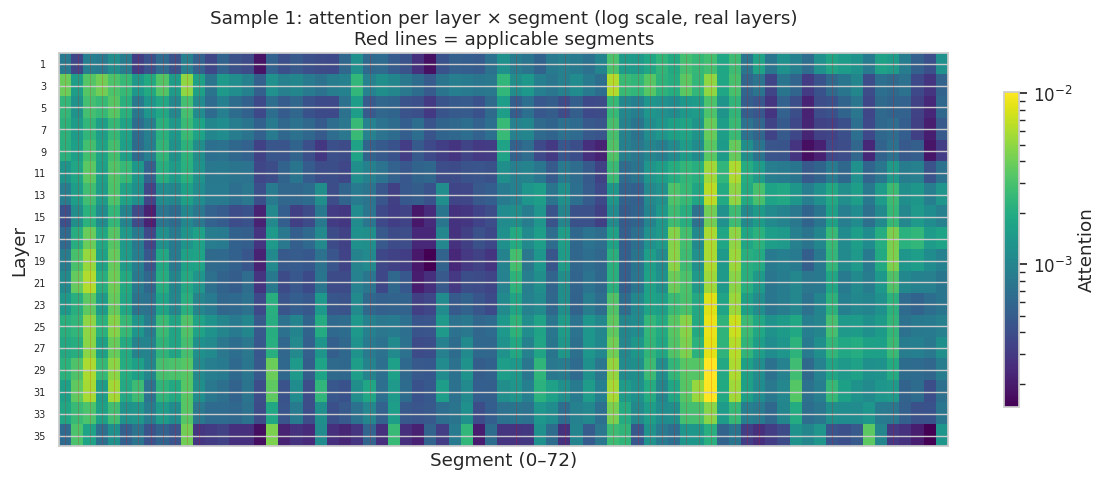

In [24]:
# Heatmap: layer × segment attention for this sample (real layers only)
layer_seg_real = np.array(s["attention_per_layer_segment"])[real_layer_indices, :]
short_names = [n.split("/")[-1][:20] for n in s["segment_names"]]  # kept for cell 26

fig, ax = plt.subplots(figsize=(12, 5))
pos_vals = layer_seg_real[layer_seg_real > 0]
if len(pos_vals) > 0:
    im = ax.imshow(layer_seg_real, aspect="auto", cmap="viridis",
                   norm=mcolors.LogNorm(vmin=max(pos_vals.min(), 1e-9),
                                         vmax=layer_seg_real.max()))
else:
    im = ax.imshow(layer_seg_real, aspect="auto", cmap="viridis")
ax.set_xlabel(f"Segment (0–{len(short_names) - 1})")
ax.set_ylabel("Layer")
ax.set_title(f"Sample {s['sample_idx']}: attention per layer × segment (log scale, real layers)\n"
             f"Red lines = applicable segments")
ax.set_xticks([])
ax.set_yticks(range(len(real_layer_indices)))
ax.set_yticklabels([str(l) for l in real_layer_indices], fontsize=7)
plt.colorbar(im, ax=ax, label="Attention", shrink=0.8)
for i, a in enumerate(s["segment_is_applicable"]):
    if a:
        ax.axvline(i, color="red", alpha=0.2, lw=0.7)
fig.tight_layout()
out_path = FIGURES_DIR / f"sample_{s['sample_idx']}_layer_segment.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

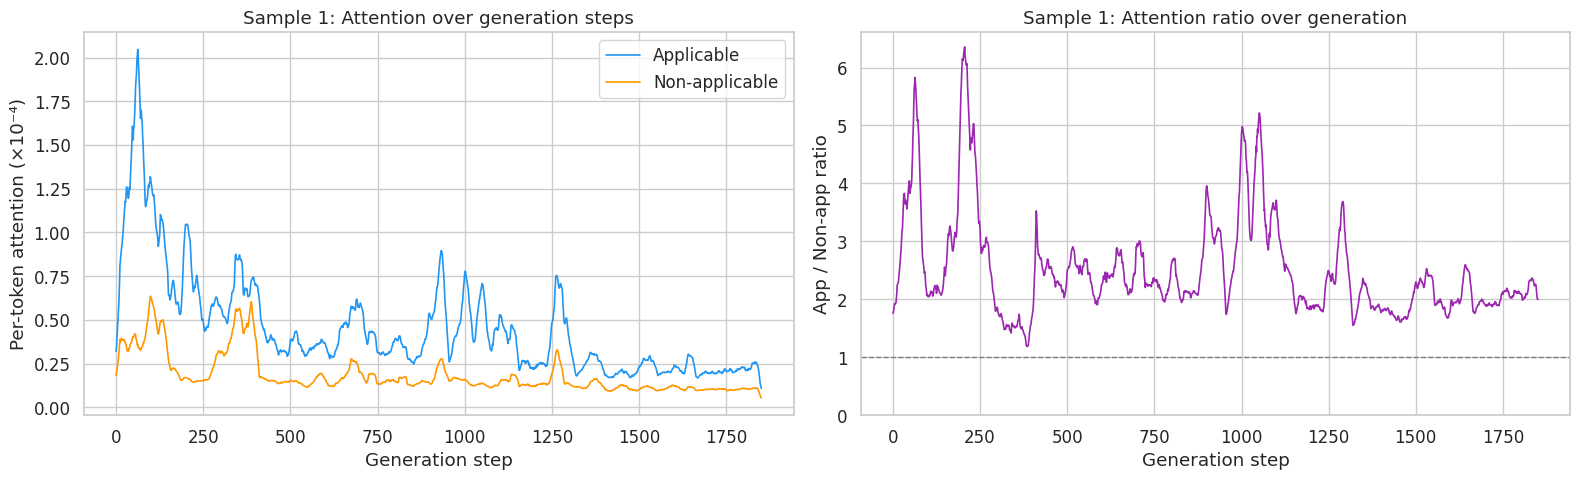

In [25]:
# Attention evolution during generation for this sample
non_mask = ~app_mask
app_tok = num_tokens_seg[app_mask].sum()
non_tok = num_tokens_seg[non_mask].sum()

# Per-step, averaged across real layers only
step_seg = cube[real_layer_indices].mean(axis=0)  # [steps, segments]
n_steps = step_seg.shape[0]

app_ts = step_seg[:, app_mask].sum(axis=1) / max(app_tok, 1)
non_ts = step_seg[:, non_mask].sum(axis=1) / max(non_tok, 1)

# Smooth
window = max(1, n_steps // 80)
if window > 1:
    kernel = np.ones(window) / window
    app_smooth = np.convolve(app_ts, kernel, mode="same")
    non_smooth = np.convolve(non_ts, kernel, mode="same")
else:
    app_smooth, non_smooth = app_ts, non_ts

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(app_smooth * 1e4, label="Applicable", color="#2196F3", lw=1.2)
ax.plot(non_smooth * 1e4, label="Non-applicable", color="#FF9800", lw=1.2)
ax.set_xlabel("Generation step")
ax.set_ylabel("Per-token attention (×10⁻⁴)")
ax.set_title(f"Sample {s['sample_idx']}: Attention over generation steps")
ax.legend()

ax = axes[1]
ratio_ts = app_smooth / np.maximum(non_smooth, 1e-15)
ax.plot(ratio_ts, color="#9C27B0", lw=1.2)
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("Generation step")
ax.set_ylabel("App / Non-app ratio")
ax.set_title(f"Sample {s['sample_idx']}: Attention ratio over generation")
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()

Saved → ../results/attention_analysis/openai_gpt-oss-120b/airline/comp_0/figures/sample_1_step_segment.png


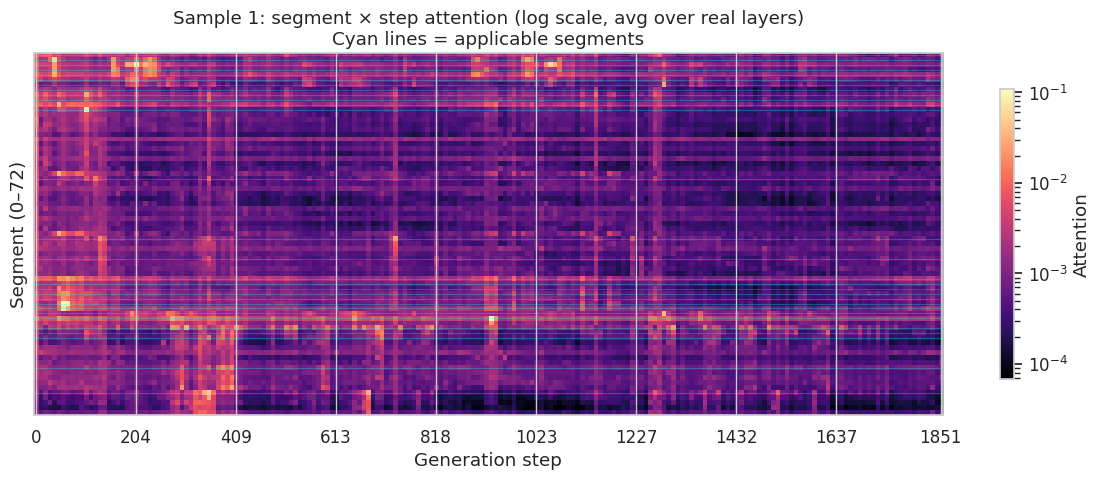

In [26]:
# Heatmap: step × segment attention (averaged across real layers) for this sample
MAX_STEPS_DISPLAY = 200
if n_steps > MAX_STEPS_DISPLAY:
    step_indices = np.linspace(0, n_steps - 1, MAX_STEPS_DISPLAY, dtype=int)
    display_data = step_seg[step_indices]
    step_labels = step_indices
else:
    display_data = step_seg
    step_labels = np.arange(n_steps)

fig, ax = plt.subplots(figsize=(12, 5))
pos_vals = display_data[display_data > 0]
if len(pos_vals) > 0:
    im = ax.imshow(display_data.T, aspect="auto", cmap="magma",
                   norm=mcolors.LogNorm(vmin=max(pos_vals.min(), 1e-9),
                                         vmax=display_data.max()))
else:
    im = ax.imshow(display_data.T, aspect="auto", cmap="magma")
ax.set_xlabel("Generation step")
ax.set_ylabel(f"Segment (0–{num_segments - 1})")
ax.set_title(f"Sample {s['sample_idx']}: segment × step attention (log scale, avg over real layers)\n"
             f"Cyan lines = applicable segments")
n_xticks = 10
xtick_pos = np.linspace(0, len(step_labels) - 1, n_xticks, dtype=int)
ax.set_xticks(xtick_pos)
ax.set_xticklabels([str(step_labels[i]) for i in xtick_pos])
ax.set_yticks([])
for i, a in enumerate(s["segment_is_applicable"]):
    if a:
        ax.axhline(i, color="cyan", alpha=0.3, lw=0.7)
plt.colorbar(im, ax=ax, label="Attention", shrink=0.8)
fig.tight_layout()
out_path = FIGURES_DIR / f"sample_{s['sample_idx']}_step_segment.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

### 6e. Per-Segment Attention Over Generation (Grouped)

Segment × generation-step heatmap for the selected sample.
Segments are reordered: **applicable rules first** (sorted by total attention), then non-applicable.
The red line marks the boundary between the two groups.

Saved → ../results/attention_analysis/openai_gpt-oss-120b/airline/comp_0/figures/sample_1_seg_step_grouped.png


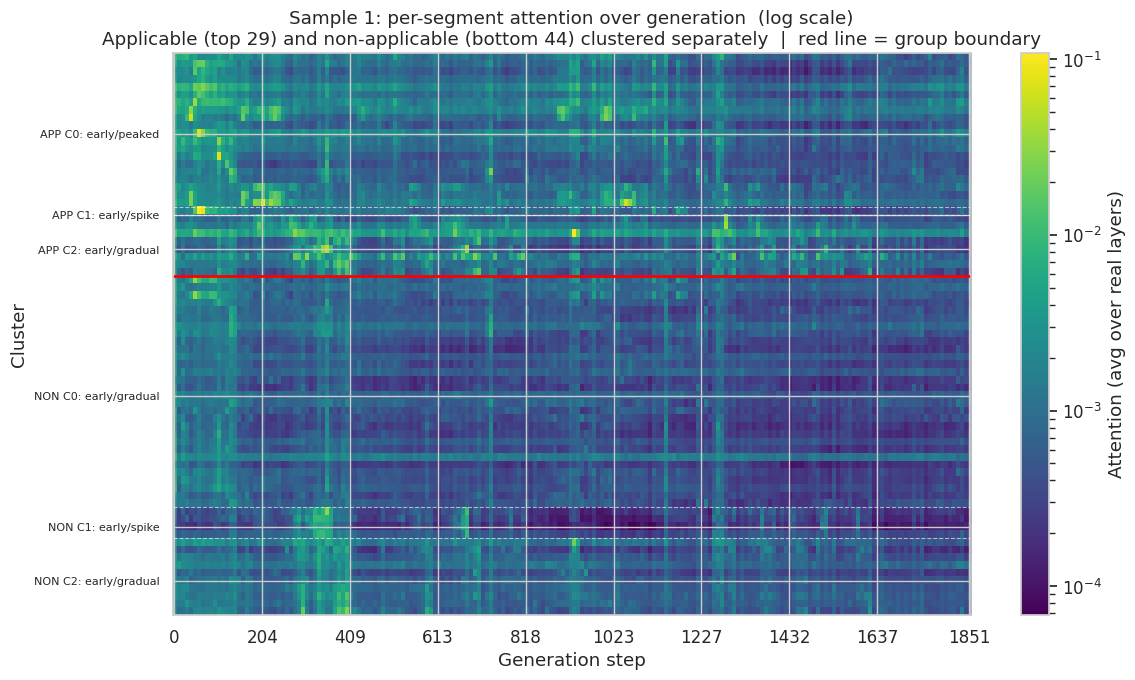


Cluster summary  (sample 1):
  APP C0: early/peaked          : 20 segments
  APP C1: early/spike           : 1 segments
  APP C2: early/gradual         : 8 segments
  NON C0: early/gradual         : 30 segments
  NON C1: early/spike           : 4 segments
  NON C2: early/gradual         : 10 segments


In [27]:
# Per-sample heatmap: separate temporal clustering within applicable and non-applicable segments
# Each group is clustered independently so intra-group patterns are visible.
N_CLUSTERS_APP = 3   # clusters within applicable segments
N_CLUSTERS_NON = 3   # clusters within non-applicable segments
N_PHASES_S     = 20  # phases used for clustering (display uses raw steps)

step_seg_real = cube[real_layer_indices].mean(axis=0)   # [steps, segments]
n_steps_s = step_seg_real.shape[0]

# Bin into phases for clustering (reduces step-level noise)
bounds_s = np.linspace(0, n_steps_s, N_PHASES_S + 1, dtype=int)
profiles_s = np.zeros((num_segments, N_PHASES_S))
for p in range(N_PHASES_S):
    chunk = step_seg_real[bounds_s[p]:bounds_s[p + 1]]
    if chunk.shape[0] > 0:
        profiles_s[:, p] = chunk.mean(axis=0)


def _cluster_group(seg_indices, n_clusters):
    """Cluster a subset of segments by temporal profile shape.
    Returns (local_order, boundaries, names) where local_order indexes into seg_indices.
    """
    profs = profiles_s[seg_indices]                      # [n_seg, N_PHASES_S]
    totals = profs.sum(axis=1, keepdims=True)
    profs_norm = profs / np.maximum(totals, 1e-15)

    k = min(n_clusters, len(seg_indices))                # can't have more clusters than segments
    if k <= 1:
        return np.arange(len(seg_indices)), [0, len(seg_indices)], ["all"]

    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    raw = km.fit_predict(profs_norm)

    # Re-rank by centroid peak phase (0 = earliest)
    c_peaks = km.cluster_centers_.argmax(axis=1)
    rmap = np.empty(k, dtype=int)
    rmap[np.argsort(c_peaks)] = np.arange(k)
    ranked = rmap[raw]

    order, boundaries, names = [], [0], []
    for ki in range(k):
        orig_ki = np.argsort(c_peaks)[ki]
        members = np.where(ranked == ki)[0]
        peak_wi = profs_norm[members].argmax(axis=1)
        order.extend(members[np.argsort(peak_wi)])
        boundaries.append(len(order))
        names.append(_cluster_name(km.cluster_centers_[orig_ki]))
    return np.array(order), boundaries, names


app_idx_s = np.where(app_mask)[0]
non_idx_s = np.where(~app_mask)[0]

app_local, app_bounds, app_names = _cluster_group(app_idx_s, N_CLUSTERS_APP)
non_local, non_bounds, non_names = _cluster_group(non_idx_s, N_CLUSTERS_NON)

# Global ordering: applicable section first, then non-applicable
app_global = app_idx_s[app_local]
non_global = non_idx_s[non_local]
seg_order_s = np.concatenate([app_global, non_global])
sep = len(app_global)                                    # row index of group separator

# Combine boundaries (offset non-app by sep)
all_bounds = app_bounds + [sep + b for b in non_bounds[1:]]
all_names  = ([f"APP C{k}: {n}" for k, n in enumerate(app_names)] +
              [f"NON C{k}: {n}" for k, n in enumerate(non_names)])

# ── Subsample steps for display ───────────────────────────────────────────────
MAX_STEPS_S = 200
if n_steps_s > MAX_STEPS_S:
    step_idx_s = np.linspace(0, n_steps_s - 1, MAX_STEPS_S, dtype=int)
    disp_s = step_seg_real[step_idx_s][:, seg_order_s]
    step_lbls_s = step_idx_s
else:
    disp_s = step_seg_real[:, seg_order_s]
    step_lbls_s = np.arange(n_steps_s)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
pos_v = disp_s.T
pos_vals_s = pos_v[pos_v > 0]
if len(pos_vals_s) > 0:
    im = ax.imshow(pos_v, aspect="auto", cmap="viridis",
                   norm=mcolors.LogNorm(vmin=max(pos_vals_s.min(), 1e-9),
                                         vmax=pos_v.max()))
else:
    im = ax.imshow(pos_v, aspect="auto", cmap="viridis")

# Solid red line between applicable / non-applicable groups
ax.axhline(sep - 0.5, color="red", lw=2)
# Dashed lines between clusters within each group
for b in all_bounds[1:-1]:
    if b != sep:
        ax.axhline(b - 0.5, color="white", lw=0.8, ls="--", alpha=0.6)

# Y-axis: cluster midpoint labels
mids_s = [(all_bounds[k] + all_bounds[k + 1]) / 2 for k in range(len(all_names))]
ax.set_yticks(mids_s)
ax.set_yticklabels(all_names, fontsize=8)

ax.set_xlabel("Generation step")
ax.set_ylabel("Cluster")
ax.set_title(
    f"Sample {s['sample_idx']}: per-segment attention over generation  (log scale)\n"
    f"Applicable (top {sep}) and non-applicable (bottom {len(non_global)}) "
    f"clustered separately  |  red line = group boundary"
)
n_xticks_s = 10
xpos_s = np.linspace(0, len(step_lbls_s) - 1, n_xticks_s, dtype=int)
ax.set_xticks(xpos_s)
ax.set_xticklabels([str(step_lbls_s[i]) for i in xpos_s])
plt.colorbar(im, ax=ax, label="Attention (avg over real layers)")
fig.tight_layout()

out_path = FIGURES_DIR / f"sample_{s['sample_idx']}_seg_step_grouped.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

print(f"\nCluster summary  (sample {s['sample_idx']}):")
for k, name in enumerate(all_names):
    start, end = all_bounds[k], all_bounds[k + 1]
    print(f"  {name:30s}: {end - start} segments")

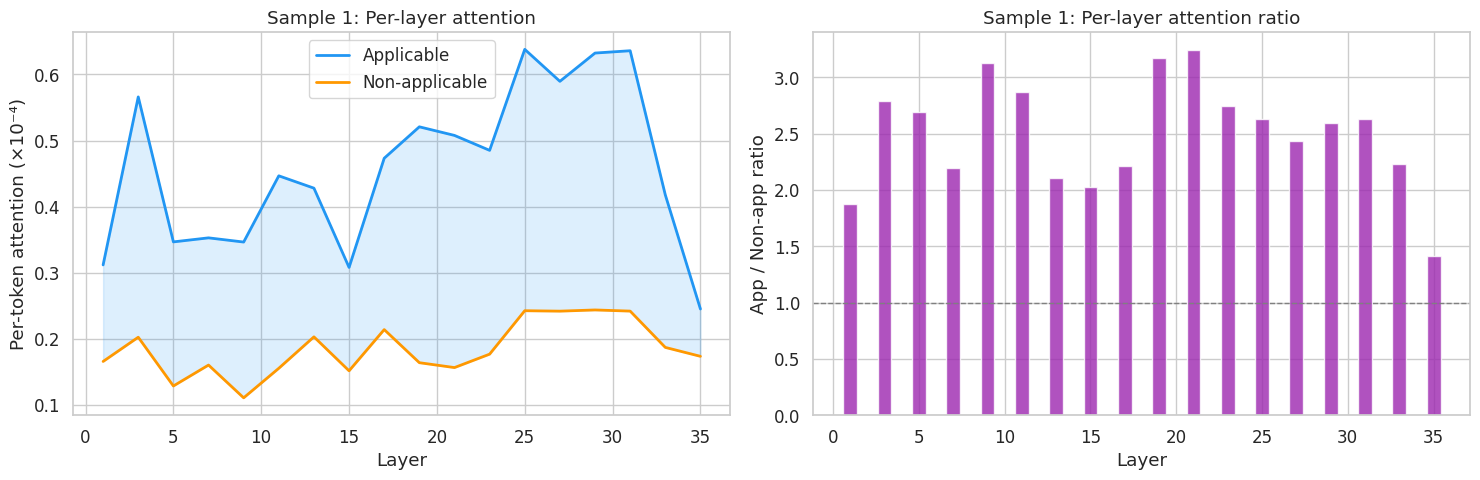

Top-5 layers for sample 1:
  Layer 21: ratio=3.24x
  Layer 19: ratio=3.18x
  Layer 9: ratio=3.12x
  Layer 11: ratio=2.87x
  Layer 3: ratio=2.79x


In [28]:
# Per-layer breakdown for the selected sample: which layers
# contribute most to applicable vs non-applicable attention?
layer_app_sample = np.zeros(num_layers)
layer_non_sample = np.zeros(num_layers)

for l in range(num_layers):
    # Average across steps → [segments]
    layer_avg = cube[l].mean(axis=0)
    layer_app_sample[l] = layer_avg[app_mask].sum() / max(app_tok, 1)
    layer_non_sample[l] = layer_avg[non_mask].sum() / max(non_tok, 1)

# Restrict to real attention layers
layer_app_s_real = layer_app_sample[real_layer_indices]
layer_non_s_real = layer_non_sample[real_layer_indices]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(real_layer_indices, layer_app_s_real * 1e4, label="Applicable", color="#2196F3", lw=2)
ax.plot(real_layer_indices, layer_non_s_real * 1e4, label="Non-applicable", color="#FF9800", lw=2)
ax.fill_between(real_layer_indices, layer_app_s_real * 1e4, layer_non_s_real * 1e4,
                alpha=0.15, color="#2196F3")
ax.set_xlabel("Layer")
ax.set_ylabel("Per-token attention (×10⁻⁴)")
ax.set_title(f"Sample {s['sample_idx']}: Per-layer attention")
ax.legend()

ax = axes[1]
layer_ratio = layer_app_s_real / np.maximum(layer_non_s_real, 1e-15)
ax.bar(real_layer_indices, layer_ratio, color="#9C27B0", alpha=0.8)
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xlabel("Layer")
ax.set_ylabel("App / Non-app ratio")
ax.set_title(f"Sample {s['sample_idx']}: Per-layer attention ratio")

fig.tight_layout()
plt.show()

top5_layers_pos = np.argsort(layer_ratio)[::-1][:5]
print(f"Top-5 layers for sample {s['sample_idx']}:")
for i in top5_layers_pos:
    l = real_layer_indices[i]
    print(f"  Layer {l}: ratio={layer_ratio[i]:.2f}x")